Cell 1 – Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

Cell 2 – Load Dataset

In [2]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Cell 3 – Dataset Information

In [3]:
print(df.shape)

print(df.columns)

df.info()

(1025, 14)
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


Cell 4 – Check Missing Values

In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Cell 5 – Statistical Summary

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Cell 6 – Target Distribution

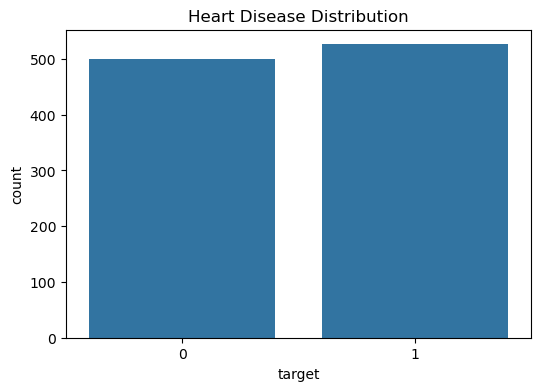

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")

plt.show()

Cell 7 – Correlation Matrix

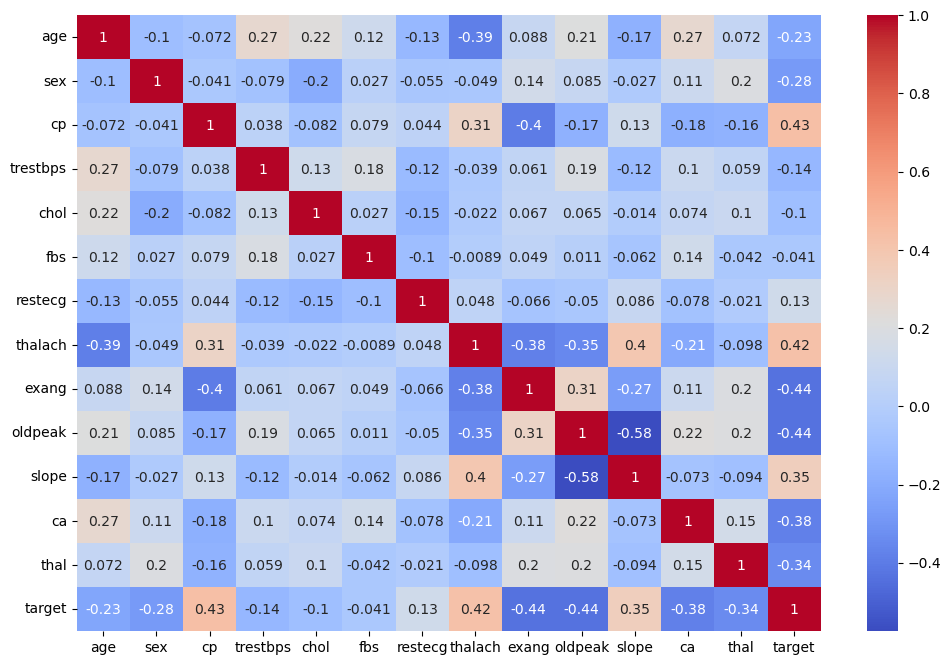

In [7]:
plt.figure(figsize=(12,8))

sns.heatmap(

    df.corr(),

    annot=True,

    cmap="coolwarm"

)

plt.show()

Cell 8 – Age Distribution

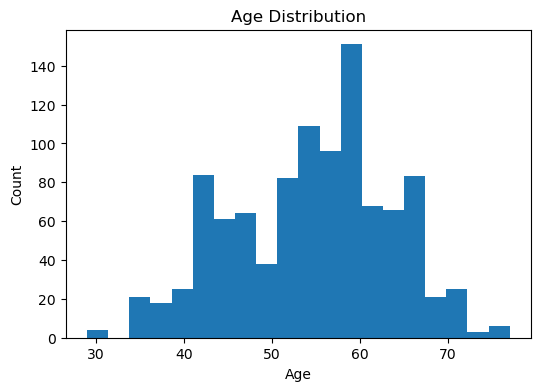

In [8]:
plt.figure(figsize=(6,4))

plt.hist(

    df["age"],

    bins=20

)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

Cell 9 – Cholesterol Distribution

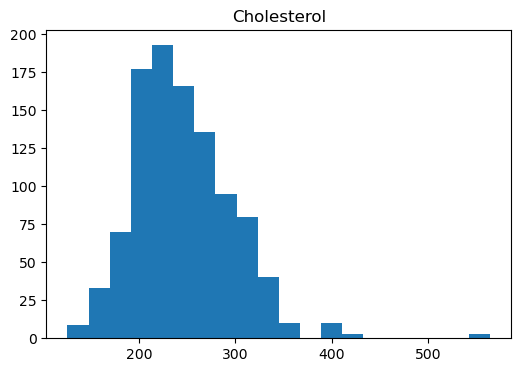

In [9]:
plt.figure(figsize=(6,4))

plt.hist(

    df["chol"],

    bins=20

)

plt.title("Cholesterol")

plt.show()

Cell 10 – Prepare Features

In [10]:
X = df.drop("target", axis=1)

y = df["target"]

Cell 11 – Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

Cell 12 – Feature Scaling

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Cell 13 – Logistic Regression

In [13]:
lr = LogisticRegression()

lr.fit(

    X_train,

    y_train

)

lr_pred = lr.predict(X_test)

print("Accuracy")

print(

    accuracy_score(

        y_test,

        lr_pred

    )

)

Accuracy
0.7951219512195122


Cell 14 – Decision Tree

In [14]:
dt = DecisionTreeClassifier(

    random_state=42

)

dt.fit(

    X_train,

    y_train

)

dt_pred = dt.predict(

    X_test

)

print(

    accuracy_score(

        y_test,

        dt_pred

    )

)

0.9853658536585366


Cell 15 – Random Forest

In [15]:
rf = RandomForestClassifier(

    random_state=42

)

rf.fit(

    X_train,

    y_train

)

rf_pred = rf.predict(

    X_test

)

print(

    accuracy_score(

        y_test,

        rf_pred

    )

)

0.9853658536585366


Cell 16 – Model Comparison

In [16]:
comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest"

    ],

    "Accuracy":[

        accuracy_score(y_test, lr_pred),

        accuracy_score(y_test, dt_pred),

        accuracy_score(y_test, rf_pred)

    ]

})

comparison

,Model,Accuracy
0,Logistic Regression,0.795122
1,Decision Tree,0.985366
2,Random Forest,0.985366


Cell 17 – Best Model

In [17]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("Best Performing Model")

print(best_model)

Best Performing Model
Model       Decision Tree
Accuracy         0.985366
Name: 1, dtype: object


Cell 18 – Classification Report (Logistic Regression)

In [18]:
print("Logistic Regression")

print(classification_report(

    y_test,

    lr_pred

))

Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



Cell 19 – Classification Report (Decision Tree)

In [19]:
print("Decision Tree")

print(classification_report(

    y_test,

    dt_pred

))

Decision Tree
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



Cell 20 – Classification Report (Random Forest)

In [20]:
print("Random Forest")

print(classification_report(

    y_test,

    rf_pred

))

Random Forest
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



Cell 21 – Confusion Matrix (Logistic Regression)

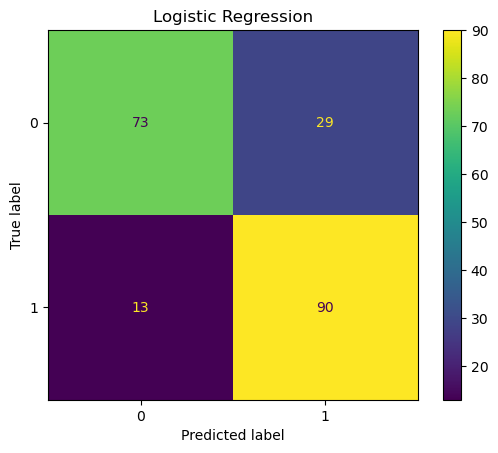

In [21]:
cm = confusion_matrix(

    y_test,

    lr_pred

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm

)

disp.plot()

plt.title("Logistic Regression")

plt.show()

Cell 22 – Confusion Matrix (Decision Tree)

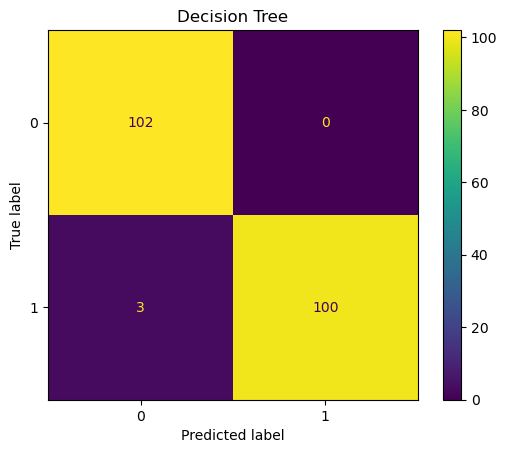

In [22]:
cm = confusion_matrix(

    y_test,

    dt_pred

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm

)

disp.plot()

plt.title("Decision Tree")

plt.show()

Cell 23 – Confusion Matrix (Random Forest)

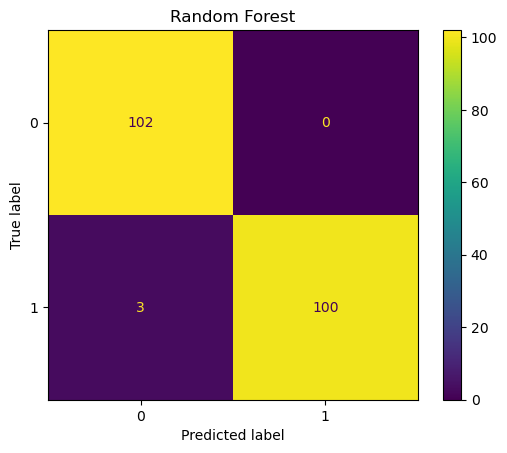

In [23]:
cm = confusion_matrix(

    y_test,

    rf_pred

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm

)

disp.plot()

plt.title("Random Forest")

plt.show()

Cell 24 – Feature Importance

In [24]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
2,cp,0.135072
11,ca,0.127327
7,thalach,0.122169
9,oldpeak,0.121905
12,thal,0.110518
0,age,0.077908
4,chol,0.074822
3,trestbps,0.071171
8,exang,0.057594
10,slope,0.045782


Cell 25 – Feature Importance Plot

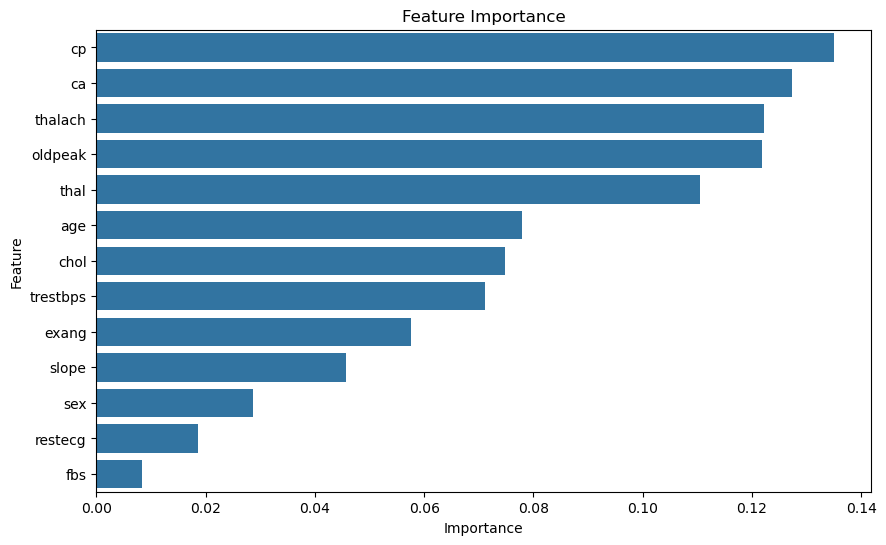

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title("Feature Importance")

plt.show()

Cell 26 – Save Model Comparison

In [26]:
comparison.to_csv(

    "model_comparison.csv",

    index=False

)

print("model_comparison.csv saved")

model_comparison.csv saved


Cell 27 – Save Predictions

In [27]:
predictions = pd.DataFrame({

    "Actual": y_test,

    "LogisticPrediction": lr_pred,

    "DecisionTreePrediction": dt_pred,

    "RandomForestPrediction": rf_pred

})

predictions.to_csv(

    "classification_predictions.csv",

    index=False

)

predictions.head()

,Actual,LogisticPrediction,DecisionTreePrediction,RandomForestPrediction
527,1,1,1,1
359,1,1,1,1
447,0,0,0,0
31,1,1,1,1
621,0,0,0,0


Cell 28 – Save Feature Importance

In [28]:
importance.to_csv(

    "feature_importance.csv",

    index=False

)

importance.head()

,Feature,Importance
2,cp,0.135072
11,ca,0.127327
7,thalach,0.122169
9,oldpeak,0.121905
12,thal,0.110518


Cell 29 – Save Processed Dataset

In [29]:
df.to_csv(

    "cleaned_heart_dataset.csv",

    index=False

)

print("Dataset saved successfully.")

Dataset saved successfully.


Cell 30 – Final Summary

In [32]:
print("="*70)

print("\nMachine Learning Models Used")

print("-----------------------------")

print("✓ Logistic Regression")

print("✓ Decision Tree")

print("✓ Random Forest")

print("\nGenerated Output Files")

print("-----------------------------")

print("cleaned_heart_dataset.csv")

print("classification_predictions.csv")

print("feature_importance.csv")

print("model_comparison.csv")




Machine Learning Models Used
-----------------------------
✓ Logistic Regression
✓ Decision Tree
✓ Random Forest

Generated Output Files
-----------------------------
cleaned_heart_dataset.csv
classification_predictions.csv
feature_importance.csv
model_comparison.csv
